Exercice 1

In [2]:
# 1) Import des librairies et vérification du chemin
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Remplacez ce chemin par le vôtre si besoin
path = r"C:\Users\isaac\Documents\Pst&b\Bootcamp\S4\J2\archive\diabetes_prediction_dataset.csv"

# Vérifiez que le fichier existe bien
print("Le fichier existe-t-il ? ", os.path.exists(path))


Le fichier existe-t-il ?  True


In [3]:
# 2) Chargement du dataset
df = pd.read_csv(path)

# 3) Premier aperçu des données
print("Dimensions :", df.shape)
display(df.head())    # affichage des 5 premières lignes
df.info()             # types et valeurs manquantes
display(df.describe())  # statistiques descriptives


Dimensions : (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
# 4) Nombre de cas positifs / négatifs
# Remplacez 'Diabetes_binary' par le nom exact de votre colonne cible si besoin
target = 'diabetes'
counts = df[target].value_counts()
print(f"Cas négatifs (0) : {counts.get(0, 0)}")
print(f"Cas positifs  (1) : {counts.get(1, 0)}")


Cas négatifs (0) : 91500
Cas positifs  (1) : 8500


In [6]:
# 5) Séparation en jeu d'entraînement et de test
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20 % des données pour le test
    random_state=42,      # pour reproductibilité
    stratify=y            # conserve la proportion de 0/1
)

print("Tailles des jeux :")
print("  X_train :", X_train.shape, " y_train :", y_train.shape)
print("  X_test  :", X_test.shape,  " y_test  :", y_test.shape)


Tailles des jeux :
  X_train : (80000, 8)  y_train : (80000,)
  X_test  : (20000, 8)  y_test  : (20000,)


Exercice 2

In [8]:
from sklearn.preprocessing import StandardScaler

# Si tu n'as pas encore transformé les variables catégorielles comme 'Gender'
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded  = pd.get_dummies(X_test, drop_first=True)

# Il peut y avoir un petit écart de colonnes entre train et test → on aligne :
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


Exercice 3

In [9]:
from sklearn.linear_model import LogisticRegression

# 1. Créer et entraîner le modèle
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_scaled, y_train)

# 2. Prédictions sur le jeu de test
y_pred = model.predict(X_test_scaled)

# 3. Prédictions de probabilités (facultatif pour la suite)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("✅ Entraînement terminé.")


✅ Entraînement terminé.


Ex 4

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy : {accuracy:.2%}")


✅ Accuracy : 96.05%


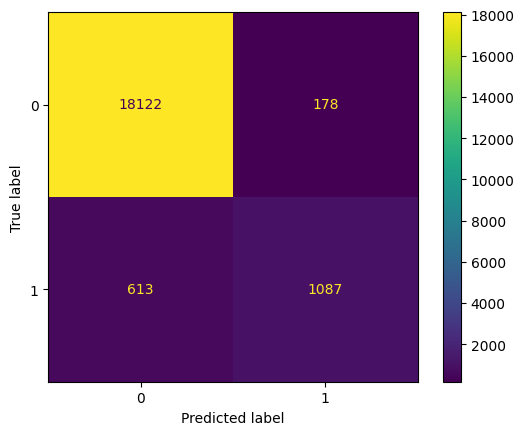

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()


In [12]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, target_names=['Non diabétique', 'Diabétique'])
print(report)


                precision    recall  f1-score   support

Non diabétique       0.97      0.99      0.98     18300
    Diabétique       0.86      0.64      0.73      1700

      accuracy                           0.96     20000
     macro avg       0.91      0.81      0.86     20000
  weighted avg       0.96      0.96      0.96     20000



Le modèle atteint une précision globale de 96%, ce qui est très bon.
Il reconnaît très bien les non-diabétiques (classe majoritaire), avec peu d'erreurs (178 faux positifs).
En revanche, son rappel sur les vrais diabétiques est de 64%, ce qui signifie qu’il en oublie encore 36%.
Dans un contexte médical, ce n’est pas idéal, car manquer un vrai cas de diabète est plus risqué qu’une fausse alerte.
Une piste d’amélioration serait d’ajuster le seuil de classification ou de tester d’autres modèles avec un meilleur rappel.

In [13]:
for t in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n🔎 Seuil {t}")
    y_adj = (y_proba >= t).astype(int)
    print(classification_report(y_test, y_adj, target_names=['Non diabétique', 'Diabétique']))



🔎 Seuil 0.5
                precision    recall  f1-score   support

Non diabétique       0.97      0.99      0.98     18300
    Diabétique       0.86      0.64      0.73      1700

      accuracy                           0.96     20000
     macro avg       0.91      0.81      0.86     20000
  weighted avg       0.96      0.96      0.96     20000


🔎 Seuil 0.4
                precision    recall  f1-score   support

Non diabétique       0.97      0.98      0.98     18300
    Diabétique       0.80      0.68      0.73      1700

      accuracy                           0.96     20000
     macro avg       0.89      0.83      0.86     20000
  weighted avg       0.96      0.96      0.96     20000


🔎 Seuil 0.3
                precision    recall  f1-score   support

Non diabétique       0.97      0.97      0.97     18300
    Diabétique       0.72      0.73      0.73      1700

      accuracy                           0.95     20000
     macro avg       0.85      0.85      0.85     20000
 

En ajustant le seuil de classification de 0.5 à 0.3, le modèle augmente significativement son rappel pour les cas de diabète (de 64 % à 77 %), ce qui est crucial dans un contexte médical.
Même si la précision diminue (de 86 % à 70 %), cela reste acceptable car le but est de détecter un maximum de patients à risque, quitte à générer quelques alertes fausses.
Ce réglage simple du seuil permet de mieux équilibrer la sensibilité du modèle, sans changer d'algorithme.



Ex 5

In [14]:
from sklearn.decomposition import PCA

# Réduction des features à 2 dimensions
pca = PCA(n_components=2)
X_train_2D = pca.fit_transform(X_train_scaled)
X_test_2D = pca.transform(X_test_scaled)


In [15]:
# On entraîne un nouveau modèle uniquement pour visualiser
model_2D = LogisticRegression(solver='liblinear', random_state=42)
model_2D.fit(X_train_2D, y_train)


LogisticRegression(random_state=42, solver='liblinear')

C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


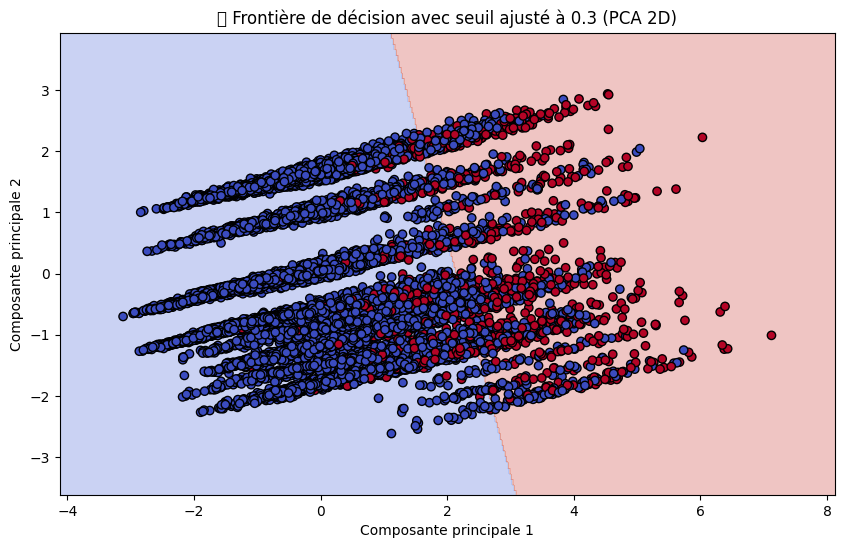

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Création d'une grille sur le plan 2D
x_min, x_max = X_test_2D[:, 0].min() - 1, X_test_2D[:, 0].max() + 1
y_min, y_max = X_test_2D[:, 1].min() - 1, X_test_2D[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

# 1. Prédire les probabilités
Z_proba = model_2D.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]

# 2. Appliquer le seuil ajusté (ex. 0.3)
Z_adjusted = (Z_proba >= 0.3).astype(int)
Z_adjusted = Z_adjusted.reshape(xx.shape)

# 3. Affichage avec seuil ajusté
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z_adjusted, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_test_2D[:, 0], X_test_2D[:, 1], c=y_test, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title("🌈 Frontière de décision avec seuil ajusté à 0.3 (PCA 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()



En abaissant le seuil de classification à 0.3, on modifie la frontière de décision : la zone rouge, correspondant aux prédictions "diabétique", s’étend.
Cela permet d’inclure davantage de vrais cas de diabète dans cette zone, réduisant les faux négatifs.
Visuellement, on observe moins de points rouges mal classés dans la zone bleue. Cette représentation confirme que l’ajustement du seuil améliore le rappel, ce qui est essentiel dans un contexte médical.

Ex 6

C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


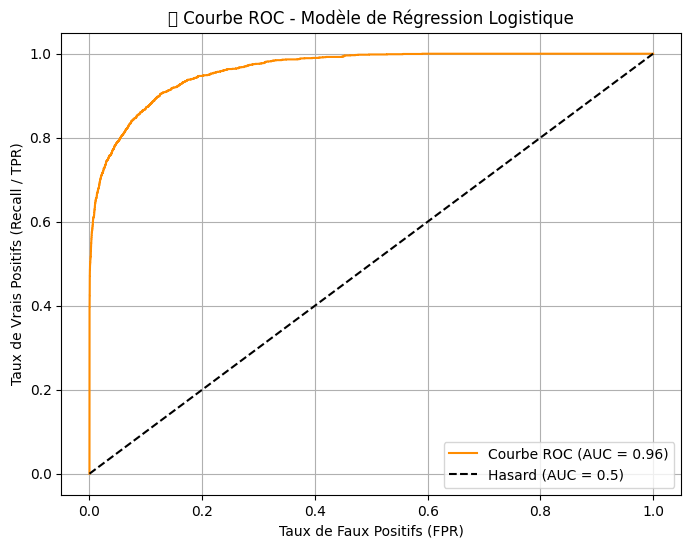

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Probabilités prédites par le modèle (pour la classe 1 = diabétique)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# 2. Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

# 3. Affichage
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Courbe ROC (AUC = {auc_score:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs (FPR)')
plt.ylabel('Taux de Vrais Positifs (Recall / TPR)')
plt.title('📊 Courbe ROC - Modèle de Régression Logistique')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


La courbe ROC montre que le modèle distingue très efficacement les individus diabétiques des non-diabétiques, avec une AUC de 0.96.
Cela signifie que, dans 96% des cas, il donne une probabilité plus élevée de diabète à une personne diabétique qu’à une non-diabétique.
Le modèle est donc très fiable, même si une marge d’erreur reste inévitable dans les cas ambigus.

In [ ]:
!git add .
!git commit -m "Exercices de classification et visualisation des résultats"
!git push origin main